In [46]:
import numpy as np

rows = []

with open("input.txt", "r") as file:
    for row in file.readlines():
        rows.append(row[:-1])


In [16]:
def max_joltage(jolts: str) -> int:
    i, first = np.argmax(list(map(int, jolts))), max(jolts, key=int)

    # max integer is final integer
    if not jolts[i + 1 :]:
        i, first = np.argmax(list(map(int, jolts[:-1]))), max(jolts[:-1], key=int)

    second = max(jolts[i + 1 :], key=int)

    return int(first + second)


ans = 0

for row in rows:
    ans += max_joltage(row)

print(ans)


17095


In [85]:
n = 100

def max_joltage_2(jolts: str) -> int:
    """
    Now take 12 digits from the joltage string
    Still want maximal joltage
    """
    max_jolts = ""
    count = 0
    i = None
    jolts_lst = list(jolts)

    while count < 12:
        if i is None:
            i, digit = np.argmax(jolts_lst[:-11]), max(jolts[:-11], key=int)
        else:
            last = i
            i, digit = (
                np.argmax(jolts_lst[last + 1 :]) + last + 1,
                max(jolts[last + 1 :], key=int),
            )

            while n - i < 12 - count:
                i, digit = (
                    np.argmax(jolts_lst[last + 1 : i]) + last + 1,
                    max(jolts[last + 1 : i], key=int),
                )

        max_jolts += digit
        count += 1

    return int(max_jolts)


ans = 0

for row in rows:
    ans += max_joltage_2(row)

assert ans == 168794698570517

print(ans)


168794698570517


In [126]:
n = 100

def max_joltage_dp(jolts: str, steps: int, n: int) -> int:
    """
    Problem is equivalent to travelling to the end in exactly 12 steps
    Objective: maximal string eval
    """
    start = np.argmax(list(jolts)[:-steps+1])
    slack = n - start - steps # number of "slack" entries
    if slack == 0:
        return int(jolts[start:])
    
    s = jolts[start]
    i = start + 1
    count = 1
    while count < steps:
        next_chara = idx = None
        for j in range(i, i+slack+1):
            if next_chara is None:
                next_chara = jolts[j]
                idx = j
            elif jolts[j] > next_chara:
                next_chara = jolts[j]
                idx = j

        slack -= idx - i
        s += next_chara
        i = idx + 1
        count += 1

    return int(s)


ans = 0

for row in rows:
    t = max_joltage_dp(row, 12, 100)
    ans += t

assert ans == 168794698570517

ans_1 = 0
for row in rows:
    t = max_joltage_dp(row, 2, 100)
    ans_1 += t

assert ans_1 == 17095
    

168794698570517


In [140]:
def max_joltage_dp_2(jolts: list[int], n: int, m: int) -> int:
    # dp backwards
    dp = [[0] * (m+1) for _ in range(n)]

    for col in range(1, m+1):
        dp[0][col] = jolts[0]

    for i in range(1, n):
        num = jolts[i]
        for j in range(m, 0, -1):
            dp[i][j] = max(dp[i-1][j-1] * 10 + num, dp[i-1][j])

    return dp[-1][-1]

max_joltage_dp_2(list(map(int, '234234234234278')), m=5, n=15)


44478

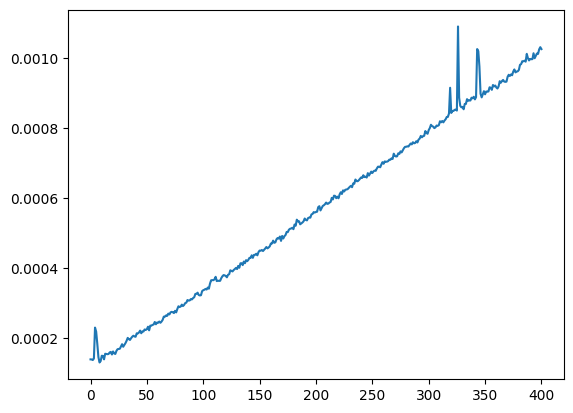

In [122]:
import matplotlib.pyplot as plt
import time

times = []

for n in range(100, 501):
    random_jolts = np.random.randint(low=1, high=10, size=100*n).astype(str)
    random_jolts = np.array_split(random_jolts, 100)

    start = time.time()
    for row in random_jolts:
        max_joltage_dp(row, 12, 100)

    end = time.time()

    times.append((end - start) / 100)

plt.plot(times)
plt.show()
